In [32]:
import numpy as np
import matplotlib.pyplot as plt
import alma4 as alma

# Elastic LNs for the PREM model

We benchmark elastic Love Numbers computed pyALMA4 for the PREM model with corresponding results from the LoadDef code by Martens et al. (2019, https://doi.org/10.1029/2018EA000462)

In [33]:
# Read the LoadDef model file

file = 'LN-by-LoadDef/PREM.txt'
data = np.genfromtxt(file)

# Reverse the 'data' array
data = np.flipud(data)

# Convert to MKS units. The first row contains r=0 so we drop it
r   = data[1:,0] * 1000
vp  = data[1:,1] * 1000
vs  = data[1:,2] * 1000
rho = data[1:,3] * 1000

# Compute mu and lambda

mu  = rho * vs**2
lam = rho * (vp**2 - 2*vs**2)

# Define the rheology

rheology = np.array( [ 'elastic' ] * len(r) )
rheology[ mu==0 ] = 'fluid'
rheology = rheology.tolist()

rpar = np.zeros( (len(r), 2) )

In [34]:
# Load reference results from LoadDef

nmax=10000 # Maximum harmonic degree that we will consider

data = np.genfromtxt( 'LN-by-LoadDef/lln_PREM.txt', skip_header=14 )
n_load_ref = data[:,0]
mask = (n_load_ref > 0) & (n_load_ref<=nmax)       # We drop the n=0 LNs for the moment
n_load_ref = n_load_ref[mask]
h_load_ref = data[mask,1]
l_load_ref = data[mask,2]/n_load_ref
k_load_ref = data[mask,3]/n_load_ref

data = np.genfromtxt( 'LN-by-LoadDef/pln_PREM.txt', skip_header=10 )
n_tide_ref = data[:,0]
mask = (n_tide_ref > 1) & (n_tide_ref <=nmax)       # We start from n=2 for the tidal case
n_tide_ref = n_tide_ref[mask]
h_tide_ref = data[mask,1]
l_tide_ref = data[mask,2]/n_tide_ref
k_tide_ref = data[mask,3]/n_tide_ref


In [35]:
# degree 1 LNs from LoadDef are in the CE, we convert them in the CM by subtracting 1

mask = n_load_ref==1

h_load_ref[ mask ] = h_load_ref[ mask ]-1
l_load_ref[ mask ] = l_load_ref[ mask ]-1
k_load_ref[ mask ] = k_load_ref[ mask ]-1


In [36]:
# Compute LNs from ALMA

n_load = list( range(1,100) ) + list( range(100,1000,10) ) + list( range(1000,10001,200) )
n_tide = list( range(2,100) ) + list( range(100,1000,10) ) + list( range(1000,10001,200) )

n_load = np.array(n_load)
n_tide = np.array(n_tide)

# Define a 'fake' viscosity profile (which will be ignored by pyALMA in elastic mode)
eta = [ 1e99 ] * len(r)

h_load, l_load, k_load = alma.love_numbers(r, rho, mu, lam, eta, rheology, rpar, n_load, 0, "loading", "elastic", verbose=True )
h_tide, l_tide, k_tide = alma.love_numbers(r, rho, mu, lam, eta, rheology, rpar, n_tide, 0, "tidal",   "elastic", verbose=True )


Harmonic degree n = 1 ( 0.29207740002311766 s )
Harmonic degree n = 2 ( 0.2882431999896653 s )
Harmonic degree n = 3 ( 0.3073339000111446 s )
Harmonic degree n = 4 ( 0.31260820000898093 s )
Harmonic degree n = 5 ( 0.30718849995173514 s )
Harmonic degree n = 6 ( 0.31884660001378506 s )
Harmonic degree n = 7 ( 0.34557639999547973 s )
Harmonic degree n = 8 ( 0.34630890004336834 s )
Harmonic degree n = 9 ( 0.32876679999753833 s )
Harmonic degree n = 10 ( 0.332754599978216 s )
Harmonic degree n = 11 ( 0.33730880002258345 s )
Harmonic degree n = 12 ( 0.34203429997432977 s )
Harmonic degree n = 13 ( 0.339869900024496 s )
Harmonic degree n = 14 ( 0.35108209995087236 s )
Harmonic degree n = 15 ( 0.356816700019408 s )
Harmonic degree n = 16 ( 0.3603624000097625 s )
Harmonic degree n = 17 ( 0.3579698000103235 s )
Harmonic degree n = 18 ( 0.3648770999861881 s )
Harmonic degree n = 19 ( 0.3788524999981746 s )
Harmonic degree n = 20 ( 0.377867300005164 s )
Harmonic degree n = 21 ( 0.1942935999832116

In [37]:
# Compute LNs from ALMA using analytical propagators

n_load_an = list( range(1,251) )  
n_tide_an = list( range(2,251) )  

n_load_an = np.array(n_load_an)
n_tide_an = np.array(n_tide_an)

h_load_an, l_load_an, k_load_an = alma.love_numbers(r, rho, mu, lam, eta, rheology, rpar, n_load_an, 0, "loading", "elastic", verbose=True, numint=False )
h_tide_an, l_tide_an, k_tide_an = alma.love_numbers(r, rho, mu, lam, eta, rheology, rpar, n_tide_an, 0, "tidal",   "elastic", verbose=True, numint=False )

Harmonic degree n = 1 ( 0.17356490000383928 s )
Harmonic degree n = 2 ( 0.1955737000098452 s )
Harmonic degree n = 3 ( 0.24294700002064928 s )
Harmonic degree n = 4 ( 0.20602359995245934 s )
Harmonic degree n = 5 ( 0.2360748000210151 s )
Harmonic degree n = 6 ( 0.21560549997957423 s )
Harmonic degree n = 7 ( 0.22407850000308827 s )
Harmonic degree n = 8 ( 0.23844340001232922 s )
Harmonic degree n = 9 ( 0.24652460002107546 s )
Harmonic degree n = 10 ( 0.2363181000109762 s )
Harmonic degree n = 11 ( 0.17297779995715246 s )
Harmonic degree n = 12 ( 0.22677190002286807 s )
Harmonic degree n = 13 ( 0.23632690001977608 s )
Harmonic degree n = 14 ( 0.21641559997806326 s )
Harmonic degree n = 15 ( 0.24752480001188815 s )
Harmonic degree n = 16 ( 0.26731339999241754 s )
Harmonic degree n = 17 ( 0.2277654000208713 s )
Harmonic degree n = 18 ( 0.21191979997092858 s )
Harmonic degree n = 19 ( 0.24108770000748336 s )
Harmonic degree n = 20 ( 0.24418999999761581 s )
Harmonic degree n = 21 ( 0.241288

In [38]:
# Compute asymptotic limits according to Boussinesq's relations
# See Farrell 1972, eq (36)

h_bq, l_bq, k_bq = alma.boussinesq(r,rho,mu,lam)


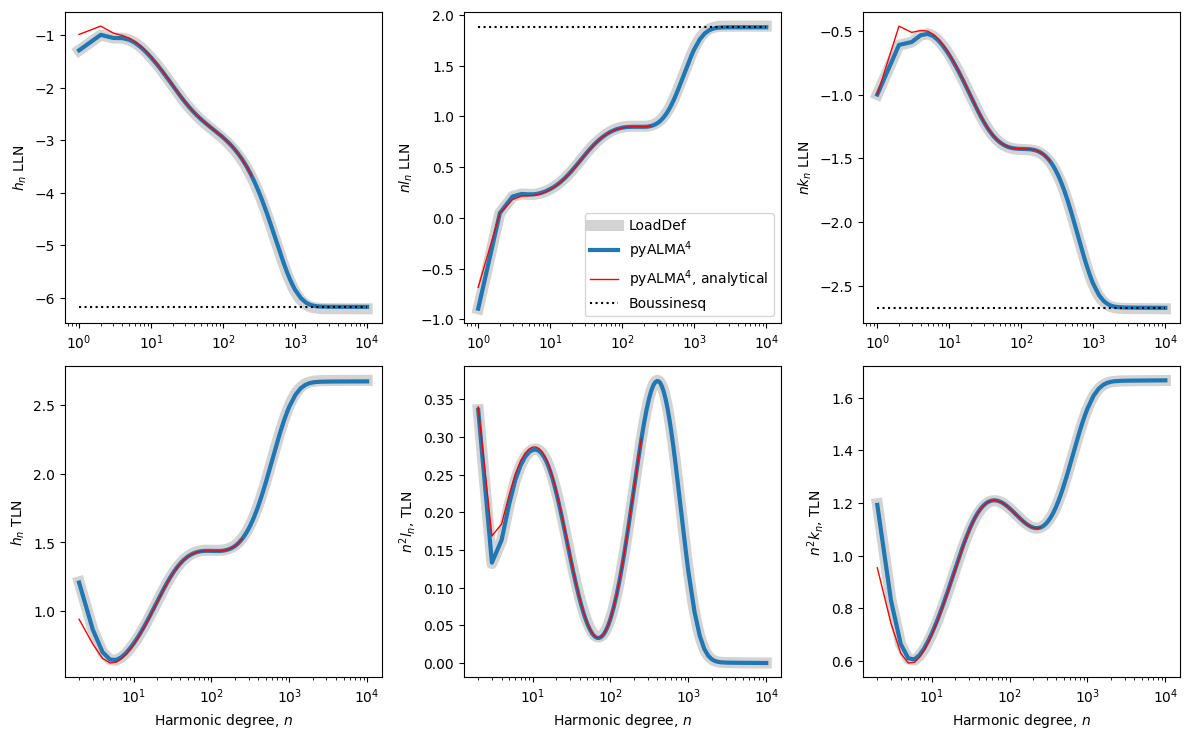

In [39]:
# Compare LNs from LoadDef, ALMA and asymptotic limits

lw1, lw2, lw3 = 8, 3, 1

fig, ax = plt.subplots( 2,3, figsize=(12,7.5) )

ax[0,0].semilogx( n_load_ref, h_load_ref, linewidth=lw1, color='lightgray', label='LoadDef' )
ax[0,0].semilogx( n_load,     h_load,     linewidth=lw2, label='pyALMA${}^4$' )
ax[0,0].semilogx( n_load_an,  h_load_an,  linewidth=lw3, color='red', label='pyALMA${}^4$, analytical' )
ax[0,0].semilogx( n_load, np.full(len(n_load), h_bq), 'k:', label='Boussinesq' )
ax[0,0].set_ylabel("$h_n$ LLN")
#ax[0,0].legend()

ax[0,1].semilogx( n_load_ref, n_load_ref*l_load_ref, linewidth=lw1, color='lightgray', label='LoadDef' )
ax[0,1].semilogx( n_load,     n_load*l_load,         linewidth=lw2, label='pyALMA${}^4$' )
ax[0,1].semilogx( n_load_an,  n_load_an*l_load_an,   linewidth=lw3, color='red', label='pyALMA${}^4$, analytical' )
ax[0,1].semilogx( n_load, np.full(len(n_load), l_bq), 'k:', label='Boussinesq' )
ax[0,1].set_ylabel("$nl_n$ LLN")
ax[0,1].legend()

ax[0,2].semilogx( n_load_ref, n_load_ref*k_load_ref, linewidth=lw1, color='lightgray' )
ax[0,2].semilogx( n_load,     n_load*k_load,         linewidth=lw2 )
ax[0,2].semilogx( n_load_an,  n_load_an*k_load_an,   linewidth=lw3, color='red' )
ax[0,2].semilogx( n_load, np.full(len(n_load), k_bq), 'k:' )
ax[0,2].set_ylabel("$nk_n$ LLN")

ax[1,0].semilogx( n_tide_ref, n_tide_ref*h_tide_ref, linewidth=lw1, color='lightgray' )
ax[1,0].semilogx( n_tide,     n_tide*h_tide,         linewidth=lw2  )
ax[1,0].semilogx( n_tide_an,  n_tide_an*h_tide_an,   linewidth=lw3, color='red' )
ax[1,0].set_ylabel('$h_n$ TLN')
ax[1,0].set_xlabel('Harmonic degree, $n$')

ax[1,1].semilogx( n_tide_ref, n_tide_ref**2*l_tide_ref, linewidth=lw1, color='lightgray' )
ax[1,1].semilogx( n_tide,     n_tide**2*l_tide,         linewidth=lw2  )
ax[1,1].semilogx( n_tide_an,  n_tide_an**2*l_tide_an,   linewidth=lw3, color='red' )
ax[1,1].set_ylabel('$n^2l_n$, TLN')
ax[1,1].set_xlabel('Harmonic degree, $n$')

ax[1,2].semilogx( n_tide_ref, n_tide_ref**2*k_tide_ref, linewidth=lw1, color='lightgray' )
ax[1,2].semilogx( n_tide,     n_tide**2*k_tide,         linewidth=lw2  )
ax[1,2].semilogx( n_tide_an,  n_tide_an**2*k_tide_an,   linewidth=lw3, color='red' )
ax[1,2].set_ylabel('$n^2k_n$, TLN')
ax[1,2].set_xlabel('Harmonic degree, $n$')

plt.tight_layout()



# Heaviside incompressible and compressible LNs for the M3-L70-V01 model, Maxwell rheology

In [40]:
# Define the model

r   = np.array([     3480.0,     5701.0,    5951.0,      6301.0, 6371.0 ] ) * 1000
rho = np.array([    10750.0,     4978.0,    3871.0,      3438.0, 3037.0 ] )
mu  = np.array([          0, 2.2834e+11, 1.0549e+11, 7.0363e+10, 5.0605e+10 ] )
lam = np.array([ 9.2629e+11, 3.0172e+11, 1.5559e+11, 1.0038e+11, 6.9170e+10 ] )
eta = np.array([          0,      2e+21,      1e+21,      1e+21,      1e+38 ] )

rheology = [ 'fluid', 'maxwell', 'maxwell', 'maxwell', 'elastic' ]
rpar     = np.zeros( (len(r),2) )


In [41]:
# Define the time axis

t = np.logspace(0,4.7,30)


In [42]:
# Compute LLNs with pyALMA

n_load = np.array([2,5,10,20,50,100])

# Incompressible

he_load, le_load, ke_load = alma.love_numbers(r, rho, mu, None, eta, rheology, rpar, n_load, 0, "loading", "elastic", verbose=True )
hv_load, lv_load, kv_load = alma.love_numbers(r, rho, mu, None, eta, rheology, rpar, n_load, t/1000, "loading", "heaviside", verbose=True )

# Compressible

hce_load, lce_load, kce_load = alma.love_numbers(r, rho, mu, lam, eta, rheology, rpar, n_load, 0, "loading", "elastic", verbose=True )
hcv_load, lcv_load, kcv_load = alma.love_numbers(r, rho, mu, lam, eta, rheology, rpar, n_load, t/1000, "loading", "heaviside", verbose=True )



Harmonic degree n = 2 ( 0.0008406000561080873 s )
Harmonic degree n = 5 ( 0.0013735999818891287 s )
Harmonic degree n = 10 ( 0.0006855999818071723 s )
Harmonic degree n = 20 ( 0.0006508000078611076 s )
Harmonic degree n = 50 ( 0.0012524999910965562 s )
Harmonic degree n = 100 ( 0.0009399999980814755 s )
Harmonic degree n = 2 ( 0.0656837000278756 s )
Harmonic degree n = 5 ( 0.05248750001192093 s )
Harmonic degree n = 10 ( 0.05332139995880425 s )
Harmonic degree n = 20 ( 0.05688759998884052 s )
Harmonic degree n = 50 ( 0.09820619999663904 s )
Harmonic degree n = 100 ( 0.07173670001793653 s )
Harmonic degree n = 2 ( 0.015588500013109297 s )
Harmonic degree n = 5 ( 0.021085400017909706 s )
Harmonic degree n = 10 ( 0.035173999960534275 s )
Harmonic degree n = 20 ( 0.05302260001190007 s )
Harmonic degree n = 50 ( 0.035448000009637326 s )
Harmonic degree n = 100 ( 0.03305189998354763 s )
Harmonic degree n = 2 ( 3.8292136000236496 s )
Harmonic degree n = 5 ( 4.982023299962748 s )
Harmonic degr

In [43]:
# Load reference results from TABOO

path_to_tb = 'LN-by-TABOO/'

data=np.genfromtxt( path_to_tb + 'loading/h.dat', skip_header=2 )
n_load_tb = data[:,0]
h_ela_load_tb =data[:,1]
h_flu_load_tb =data[:,2]
h_res_load_tb =data[:,3:]

nroots = h_res_load_tb.shape[1]

spectrum=np.genfromtxt( path_to_tb + 'loading/spectrum.dat', skip_header=7 )

# Rebuild heaviside LNs from TABOO

h_load_tb = np.zeros((len(n_load_tb), len(t)))

for i in range(len(n_load_tb)):
    h_load_tb[i,:] = h_flu_load_tb[i]
    mask    = spectrum[:,0].astype(int) == n_load_tb[i]
    s_roots = spectrum[mask, 2] 
    
    for j in range(nroots):
        h_load_tb[i,:] += (h_res_load_tb[i,j] / s_roots[j]) * np.exp( s_roots[j]*t/1000 )



In [45]:
# Load reference results from ISSM

dir_name = 'LN-by-ISSM/heaviside'

data = np.genfromtxt( dir_name + '/h-load-heaviside-M3L70V01-Maxwell-compressible.dat', skip_header=4 )
n_load_issm  = data[:,0]
hc_load_issm = data[:,1:]

data = np.genfromtxt( dir_name + '/l-load-heaviside-M3L70V01-Maxwell-compressible.dat', skip_header=4 )
lc_load_issm = data[:,1:]

data = np.genfromtxt( dir_name + '/k-load-heaviside-M3L70V01-Maxwell-compressible.dat', skip_header=4 )
kc_load_issm = data[:,1:]


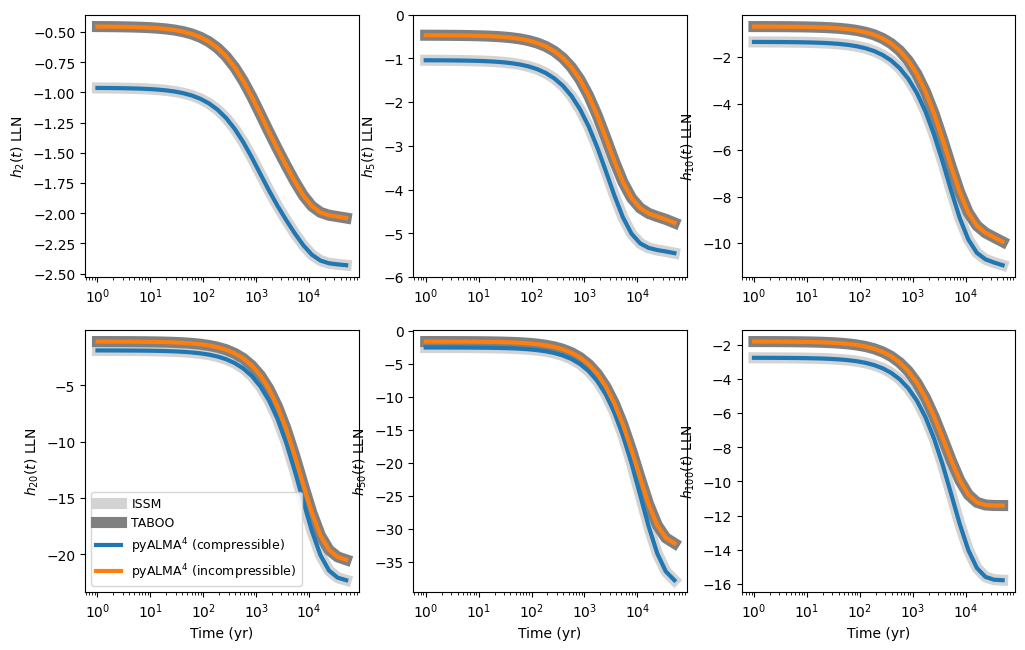

In [46]:
# 

n_plot = [2, 5, 10, 20, 50, 100]

lw1, lw2 = 8, 3

fig, ax = plt.subplots( 2,3, figsize=(12,7.5) )

k=0
for i in range(2):
    for j in range(3):

        idx      = np.where( n_load==n_plot[k] )[0][0]
        idx_issm = np.where( n_load_issm==n_plot[k] )[0][0]
        idx_tb   = np.where( n_load_tb.astype(int) == n_plot[k] )[0][0]

        ax[i,j].semilogx( t, hc_load_issm[idx_issm,1:],  linewidth=lw1, color='lightgray', label='ISSM')
        #ax[i,j].semilogx( t, h_load_issm[idx_issm,1:], linewidth=lw1, color='gray',      label='ISSM (incompressible)'  )
        ax[i,j].semilogx( t, h_load_tb[idx_tb,:],       linewidth=lw1, color='gray',      label='TABOO'  )
        ax[i,j].semilogx( t, hcv_load[idx,:],            linewidth=lw2, label='pyALMA${}^4$ (compressible)' )
        ax[i,j].semilogx( t, hv_load[idx,:],           linewidth=lw2, label='pyALMA${}^4$ (incompressible)' )

        ax[i,j].set_ylabel( '$h_{'+str(n_plot[k])+'}(t)$ LLN' )

        if k==3:
            ax[i,j].legend(fontsize=9)

        if i==1:
            ax[i,j].set_xlabel('Time (yr)')

        #ax[i,j].set_xlim(5,6e4)
        if (i==0) & (j==1):
            ax[i,j].set_ylim(-6,0)

        k+=1



# Fluid LNs for the M3-L70-V01 model

In [47]:
# Define the model from Table 3 of Spada et al. (2011), https://doi.org/10.1111/j.1365-246X.2011.04952.x

r   = np.array([3.480e6, 5.701e6, 5.951e6, 6.301e6, 6.371e6])
rho = np.array([10750.0, 4978.0, 3871.0, 3438.0, 3037.0])
mu  = np.array([0, 2.28340, 1.05490, 0.70363, 0.50605]) * 1e11
lam = None    # Model is incompressible
eta = np.array([0, 2, 1, 1, 1e10]) * 1e21

rheology = [ 'fluid', 'maxwell', 'maxwell', 'maxwell', 'elastic']

params = np.zeros((len(r),2))

In [48]:
# Load reference results with TABOO

path_to_tb = 'LN-by-TABOO/'

data=np.genfromtxt( path_to_tb + 'loading/h.dat', skip_header=2 )
n_load_tb = data[:,0]
h_ela_load_tb =data[:,1]
h_flu_load_tb =data[:,2]

data=np.genfromtxt( path_to_tb + 'loading/l.dat', skip_header=2 )
l_ela_load_tb =data[:,1]
l_flu_load_tb =data[:,2]

data=np.genfromtxt( path_to_tb + 'loading/k.dat', skip_header=2 )
k_ela_load_tb =data[:,1]
k_flu_load_tb =data[:,2]

#

data=np.genfromtxt( path_to_tb + 'tidal/h.dat', skip_header=2 )
n_tide_tb = data[:,0]
h_ela_tide_tb =data[:,1]
h_flu_tide_tb =data[:,2]

data=np.genfromtxt( path_to_tb + 'tidal/l.dat', skip_header=2 )
l_ela_tide_tb =data[:,1]
l_flu_tide_tb =data[:,2]

data=np.genfromtxt( path_to_tb + 'tidal/k.dat', skip_header=2 )
k_ela_tide_tb =data[:,1]
k_flu_tide_tb =data[:,2]


In [49]:
# Compute the elastic and fluid LNs with pyALMA

nmax = 1000
n_load = np.arange(1,nmax+1)
n_tide = np.arange(2,nmax+1)

# Elastic analysis

h_ela_load, l_ela_load, k_ela_load = alma.love_numbers(r,rho,mu,lam,eta,rheology,params,n_load,0,"loading","elastic")
h_ela_tide, l_ela_tide, k_ela_tide = alma.love_numbers(r,rho,mu,lam,eta,rheology,params,n_tide,0,"tidal",  "elastic")

# Fluid limit

h_flu_load, l_flu_load, k_flu_load = alma.love_numbers(r,rho,mu,lam,eta,rheology,params,n_load,0,"loading","fluid")
h_flu_tide, l_flu_tide, k_flu_tide = alma.love_numbers(r,rho,mu,lam,eta,rheology,params,n_tide,0,"tidal",  "fluid")

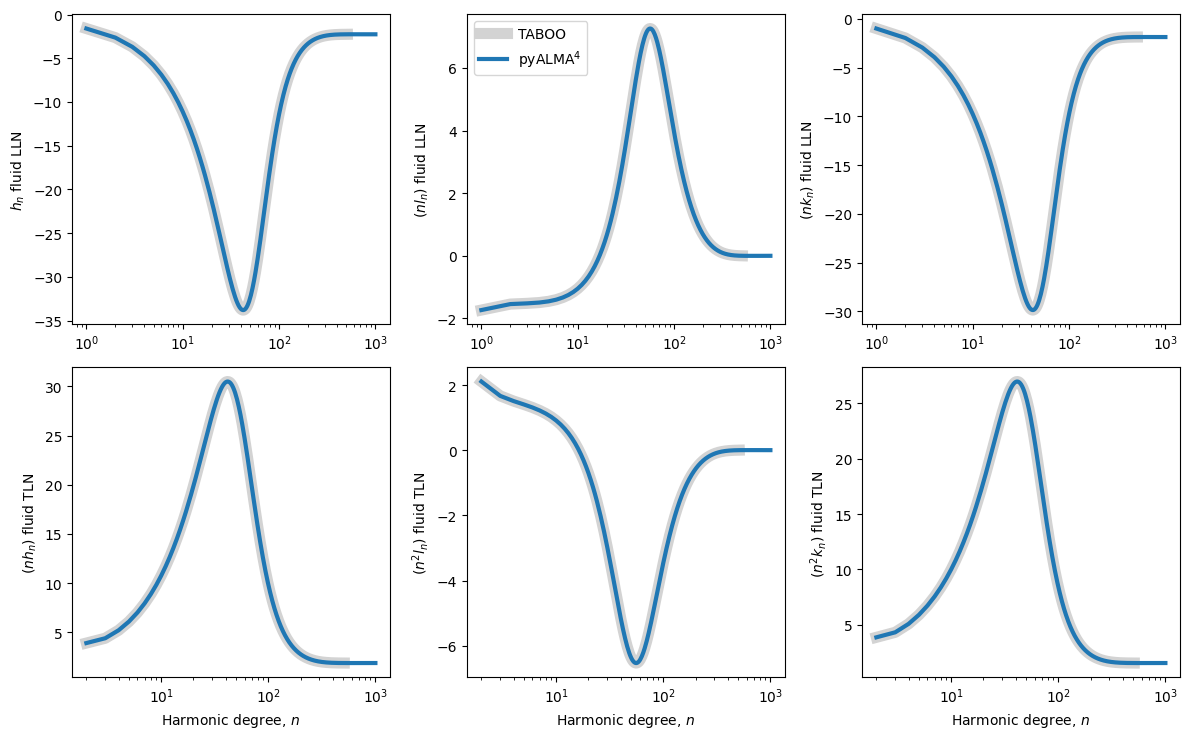

In [50]:
# Plot fluid LNs

lw1, lw2 = 8, 3

fig, ax = plt.subplots( 2,3, figsize=(12,7.5) )

ax[0,0].semilogx( n_load_tb, h_flu_load_tb, linewidth=lw1, color='lightgray'  )
ax[0,0].semilogx( n_load,    h_flu_load,    linewidth=lw2  )
ax[0,0].set_ylabel('$h_n$ fluid LLN')

ax[0,1].semilogx( n_load_tb, n_load_tb*l_flu_load_tb, linewidth=lw1, color='lightgray', label='TABOO'  )
ax[0,1].semilogx( n_load,    n_load   *l_flu_load,    linewidth=lw2, label='pyALMA${}^4$'  )
ax[0,1].set_ylabel('$(n l_n)$ fluid LLN')
ax[0,1].legend(loc='upper left')

ax[0,2].semilogx( n_load_tb, n_load_tb*k_flu_load_tb, linewidth=lw1, color='lightgray'  )
ax[0,2].semilogx( n_load,    n_load   *k_flu_load,    linewidth=lw2  )
ax[0,2].set_ylabel('$(n k_n)$ fluid LLN')

ax[1,0].semilogx( n_tide_tb, n_tide_tb*h_flu_tide_tb, linewidth=lw1, color='lightgray'   )
ax[1,0].semilogx( n_tide,    n_tide   *h_flu_tide,    linewidth=lw2  )
ax[1,0].set_ylabel('$(n h_n)$ fluid TLN')
ax[1,0].set_xlabel('Harmonic degree, $n$')

ax[1,1].semilogx( n_tide_tb, (n_tide_tb**2) *l_flu_tide_tb, linewidth=lw1, color='lightgray'   )
ax[1,1].semilogx( n_tide,    (n_tide**2)    *l_flu_tide,    linewidth=lw2  )
ax[1,1].set_ylabel('$(n^2 l_n)$ fluid TLN')
ax[1,1].set_xlabel('Harmonic degree, $n$')

ax[1,2].semilogx( n_tide_tb, n_tide_tb**2 * k_flu_tide_tb, linewidth=lw1, color='lightgray',     label='TABOO'  )
ax[1,2].semilogx( n_tide,    n_tide**2    * k_flu_tide,    linewidth=lw2,                        label='pyALMA4' )
ax[1,2].set_ylabel('$(n^2 k_n)$ fluid TLN ')
ax[1,2].set_xlabel('Harmonic degree, $n$')

plt.tight_layout()


# Heaviside LNs for transient Burgers and EBM rheologies

In [51]:
# Define the model

# Elastic profile
r   = np.array([     3480.0,     5701.0,    5951.0,      6301.0, 6371.0 ] ) * 1000
rho = np.array([    10750.0,     4978.0,    3871.0,      3438.0, 3037.0 ] )
mu  = np.array([          0, 2.2834e+11, 1.0549e+11, 7.0363e+10, 5.0605e+10 ] )
lam = np.array([ 9.2629e+11, 3.0172e+11, 1.5559e+11, 1.0038e+11, 6.9170e+10 ] )

nla = len(r)
yts = 365.25 * 24 * 3600

# Maxwell
eta_mx      = np.array([          0,    2.0e+21,    1.0e+21,    1.0e+21,      1e+99 ])
rheology_mx = [ 'fluid', 'maxwell', 'maxwell', 'maxwell', 'elastic' ]
rpar_mx     = np.zeros((nla,2))

# Burgers
eta_bg      = np.copy(eta_mx)
rheology_bg = [ 'fluid', 'burgers', 'burgers', 'burgers', 'elastic' ]
rpar_bg     = np.zeros((nla,2))
for i in range(1,4):
    rpar_bg[i,:] = np.array([0.1, 0.01])

# EBM
#alpha = 0.4
#delta = 0.9
#tauL  = 54*60 / yts / 1000
#tauH  = 7.134 / 1000
alpha, delta = 0.4, 0.9
tauL, tauH   = (1/12) / 1000 , 7 / 1000
eta_eb      = np.copy(eta_mx)
rheology_eb = [ 'fluid', 'ebm', 'ebm', 'ebm', 'elastic' ]
rpar_eb     = np.zeros((nla,4))
for i in range(1,4):
    rpar_eb[i,:] = np.array([alpha, delta, tauL, tauH])



In [52]:
# Define the time axis

t = np.logspace(-3,4.7,50)


In [53]:
# Compute LLNs with pyALMA

n_load = np.array([2,5,10,20,50,100])

hc_mx_load, lc_mx_load, kc_mx_load = alma.love_numbers(r, rho, mu, lam, eta_mx, rheology_mx, rpar_mx, n_load, t/1000, "loading", "heaviside", verbose=True )
hc_bg_load, lc_bg_load, kc_bg_load = alma.love_numbers(r, rho, mu, lam, eta_bg, rheology_bg, rpar_bg, n_load, t/1000, "loading", "heaviside", verbose=True )
hc_eb_load, lc_eb_load, kc_eb_load = alma.love_numbers(r, rho, mu, lam, eta_eb, rheology_eb, rpar_eb, n_load, t/1000, "loading", "heaviside", verbose=True )



Harmonic degree n = 2 ( 6.405932699970435 s )
Harmonic degree n = 5 ( 8.579171899997164 s )
Harmonic degree n = 10 ( 11.91912090004189 s )
Harmonic degree n = 20 ( 19.53638329997193 s )
Harmonic degree n = 50 ( 14.659194600011688 s )
Harmonic degree n = 100 ( 13.845672000024933 s )
Harmonic degree n = 2 ( 6.400838899950031 s )
Harmonic degree n = 5 ( 8.249570600048173 s )
Harmonic degree n = 10 ( 11.328583399998024 s )
Harmonic degree n = 20 ( 19.534849699994083 s )
Harmonic degree n = 50 ( 14.600188899959903 s )
Harmonic degree n = 100 ( 13.65388840000378 s )
Harmonic degree n = 2 ( 6.554533300048206 s )
Harmonic degree n = 5 ( 8.756412999995518 s )
Harmonic degree n = 10 ( 11.844486499961931 s )
Harmonic degree n = 20 ( 19.603312699997332 s )
Harmonic degree n = 50 ( 14.745188000029884 s )
Harmonic degree n = 100 ( 13.94613080000272 s )


In [54]:
# Load reference results from ISSM

dir_name = 'LN-by-ISSM/heaviside'

# Burgers

data = np.genfromtxt( dir_name + '/h-load-heaviside-M3L70V01-Burgers-compressible.dat', skip_header=4 )
n_load_issm = data[:,0]
hc_bg_load_issm = data[:,1:]

data = np.genfromtxt( dir_name + '/l-load-heaviside-M3L70V01-Burgers-compressible.dat', skip_header=4 )
lc_bg_load_issm = data[:,1:]

data = np.genfromtxt( dir_name + '/k-load-heaviside-M3L70V01-Burgers-compressible.dat', skip_header=4 )
kc_bg_load_issm = data[:,1:]

# EBM

data = np.genfromtxt( dir_name + '/h-load-heaviside-M3L70V01-EBM-compressible.dat', skip_header=4 )
n_load_issm = data[:,0]
hc_eb_load_issm = data[:,1:]

data = np.genfromtxt( dir_name + '/l-load-heaviside-M3L70V01-EBM-compressible.dat', skip_header=4 )
lc_eb_load_issm = data[:,1:]

data = np.genfromtxt( dir_name + '/k-load-heaviside-M3L70V01-EBM-compressible.dat', skip_header=4 )
kc_eb_load_issm = data[:,1:]


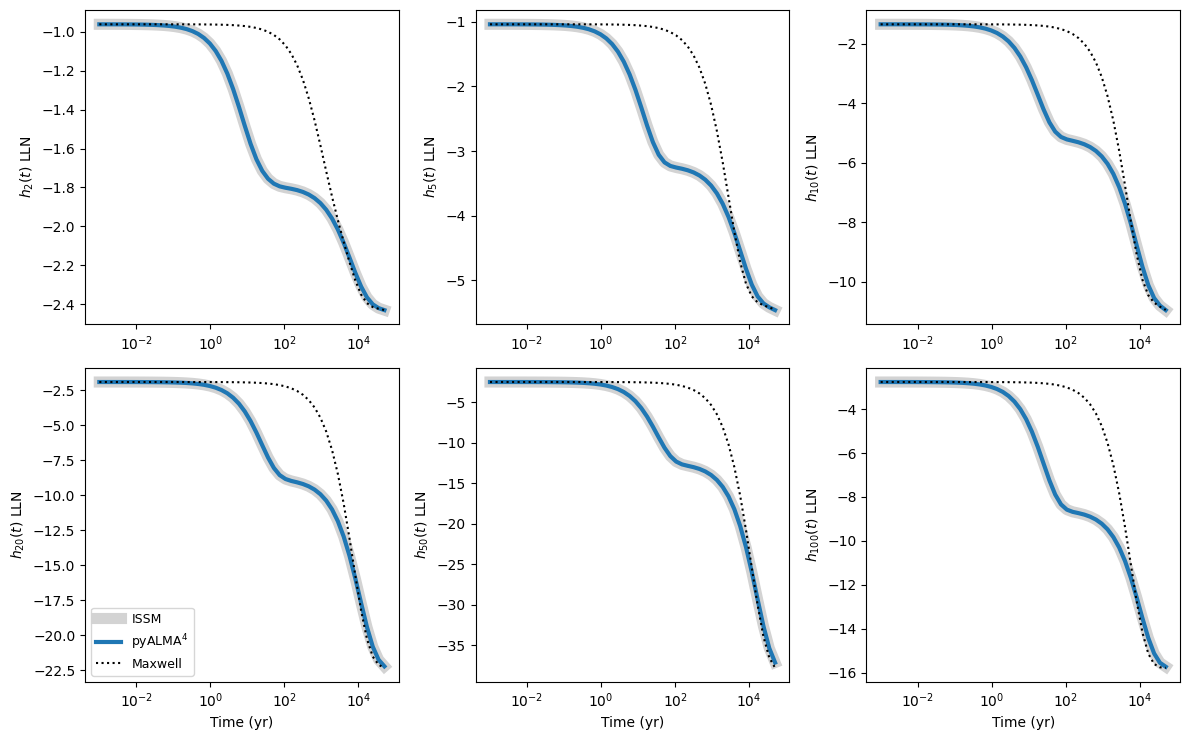

In [55]:
# 

n_plot = [2, 5, 10, 20, 50, 100]

lw1, lw2 = 8, 3

fig, ax = plt.subplots( 2,3, figsize=(12,7.5) )

k=0
for i in range(2):
    for j in range(3):

        idx      = np.where( n_load==n_plot[k] )[0][0]
        idx_issm = np.where( n_load_issm==n_plot[k] )[0][0]

        ax[i,j].semilogx( t, hc_bg_load_issm[idx_issm,1:],  linewidth=lw1, color='lightgray', label='ISSM')
        ax[i,j].semilogx( t, hc_bg_load[idx,:],             linewidth=lw2, label='pyALMA${}^4$' )
        ax[i,j].semilogx( t, hc_mx_load[idx,:], 'k:', label='Maxwell' )
     
        ax[i,j].set_ylabel( '$h_{'+str(n_plot[k])+'}(t)$ LLN' )

        if k==3:
            ax[i,j].legend(fontsize=9)

        if i==1:
            ax[i,j].set_xlabel('Time (yr)')

        k+=1

plt.tight_layout()


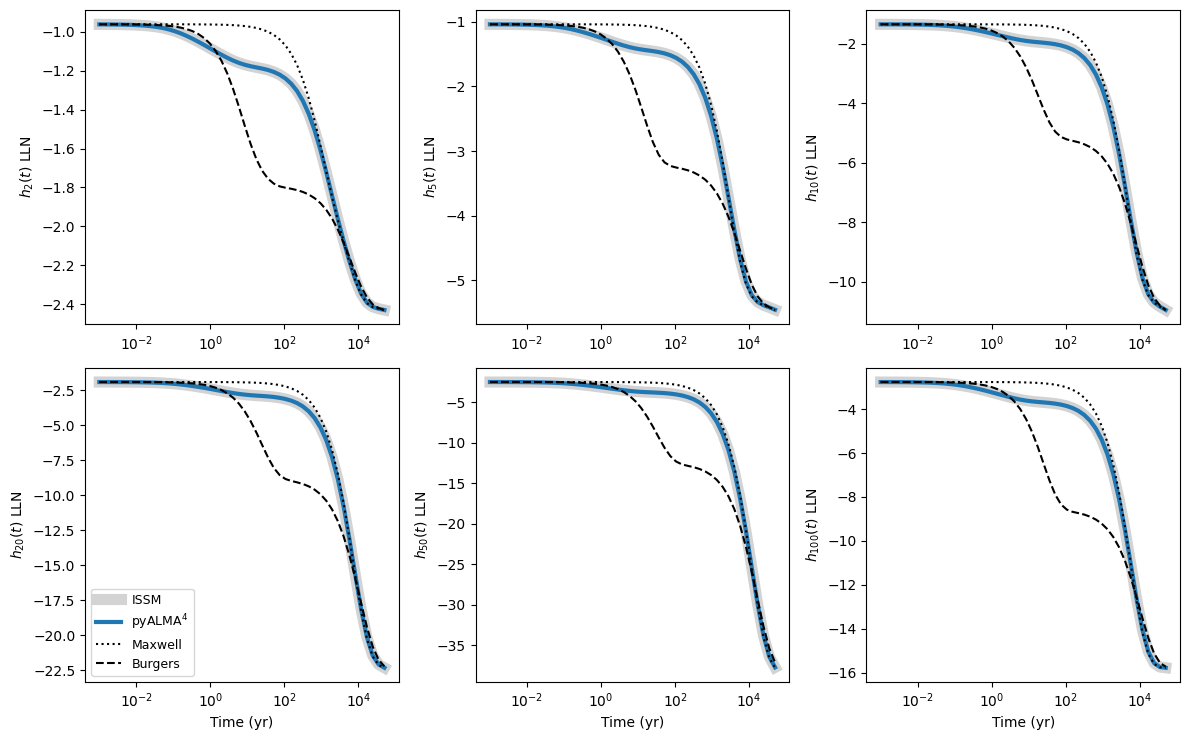

In [56]:
# 

n_plot = [2, 5, 10, 20, 50, 100]

lw1, lw2 = 8, 3

fig, ax = plt.subplots( 2,3, figsize=(12,7.5) )

k=0
for i in range(2):
    for j in range(3):

        idx      = np.where( n_load==n_plot[k] )[0][0]
        idx_issm = np.where( n_load_issm==n_plot[k] )[0][0]

        ax[i,j].semilogx( t, hc_eb_load_issm[idx_issm,1:],   linewidth=lw1, color='lightgray', label='ISSM')
        ax[i,j].semilogx( t, hc_eb_load[idx,:],             linewidth=lw2, label='pyALMA${}^4$' )
        ax[i,j].semilogx( t, hc_mx_load[idx,:], 'k:', label='Maxwell' )
        ax[i,j].semilogx( t, hc_bg_load[idx,:], 'k--', label='Burgers' )

        ax[i,j].set_ylabel( '$h_{'+str(n_plot[k])+'}(t)$ LLN' )

        if k==3:
            ax[i,j].legend(fontsize=9)

        if i==1:
            ax[i,j].set_xlabel('Time (yr)')

        k+=1

plt.tight_layout()



# Complex LNs for a periodic load

In [57]:
# year-to-seconds

yts=365.25*24*3600

# Define the model
r   = np.array([     3480.0,     5701.0,    5951.0,      6301.0, 6371.0 ] ) * 1000
rho = np.array([    10750.0,     4978.0,    3871.0,      3438.0, 3037.0 ] )
mu  = np.array([          0, 2.2834e+11, 1.0549e+11, 7.0363e+10, 5.0605e+10 ] )
lam = np.array([ 9.2629e+11, 3.0172e+11, 1.5559e+11, 1.0038e+11, 6.9170e+10 ] )
eta = np.array([          0,      2e+21,      1e+21,      1e+21,      1e+38] )
nla = len(r)

# Rheology definition for the Maxwell model
rheology_mx = [ 'fluid', 'maxwell', 'maxwell', 'maxwell', 'elastic' ]
rpar_mx     = np.zeros( (len(r),2) )

# Rheology definition for the Burgers model
rheology_bg = [ 'fluid', 'burgers', 'burgers', 'burgers', 'elastic' ]
rpar_bg     = np.array( [ [0, 0], [0.1, 0.01], [0.1, 0.01], [0.1, 0.01], [0, 0] ] )

# Rheology definition for the EBM model
rheology_eb = [ 'fluid', 'ebm', 'ebm', 'ebm', 'elastic' ]
rpar_eb     = np.zeros((5,4))

alpha = 0.4
delta = 0.9
tauL  = 54*60 / yts / 1000
tauH  = 7.134 / 1000

for i in range(nla):
    rpar_eb[i,:] = np.array([alpha,delta,tauL,tauH])




In [58]:
# Define the periods

Tyr  = np.logspace(-3,8,200)
Tkyr = Tyr/1000

In [59]:
# Compute LNs with ALMA

h_tide_mx,  l_tide_mx,  k_tide_mx  = alma.love_numbers(r, rho, mu, None, eta, rheology_mx, rpar_mx, 2, Tkyr, "tidal",   "frequency", verbose=True )
hc_tide_mx, lc_tide_mx, kc_tide_mx = alma.love_numbers(r, rho, mu, lam,  eta, rheology_mx, rpar_mx, 2, Tkyr, "tidal",   "frequency", verbose=True )

h_tide_bg,  l_tide_bg,  k_tide_bg  = alma.love_numbers(r, rho, mu, None, eta, rheology_bg, rpar_bg, 2, Tkyr, "tidal",   "frequency", verbose=True )
hc_tide_bg, lc_tide_bg, kc_tide_bg = alma.love_numbers(r, rho, mu, lam,  eta, rheology_bg, rpar_bg, 2, Tkyr, "tidal",   "frequency", verbose=True )

h_tide_eb,  l_tide_eb,  k_tide_eb  = alma.love_numbers(r, rho, mu, None, eta, rheology_eb, rpar_eb, 2, Tkyr, "tidal",   "frequency", verbose=True )
hc_tide_eb, lc_tide_eb, kc_tide_eb = alma.love_numbers(r, rho, mu, lam,  eta, rheology_eb, rpar_eb, 2, Tkyr, "tidal",   "frequency", verbose=True )


Harmonic degree n = 2 ( 0.08871310000540689 s )
Harmonic degree n = 2 ( 3.789722100016661 s )
Harmonic degree n = 2 ( 0.037423300032969564 s )
Harmonic degree n = 2 ( 4.067516900016926 s )
Harmonic degree n = 2 ( 0.04198879998875782 s )
Harmonic degree n = 2 ( 4.444532599998638 s )


In [60]:
# Load reference results from ISSM

dir_name = 'LN-by-ISSM/periodic'

# Incompressible TLNs, Maxwell rheology

data = np.genfromtxt( dir_name + '/tln-complex-M3L70V01-Maxwell-incompressible.dat', skip_header=4 )
Tyr_issm = data[:,0]
h_tide_mx_issm = data[:,1] + 1j * data[:,2]
l_tide_mx_issm = data[:,3] + 1j * data[:,4]
k_tide_mx_issm = data[:,5] + 1j * data[:,6]

# Compressible TLNs, Maxwell rheology

data = np.genfromtxt( dir_name + '/tln-complex-M3L70V01-Maxwell-compressible.dat', skip_header=4 )
hc_tide_mx_issm = data[:,1] + 1j * data[:,2]
lc_tide_mx_issm = data[:,3] + 1j * data[:,4]
kc_tide_mx_issm = data[:,5] + 1j * data[:,6]



# Incompressible TLNs, Burgers rheology

data = np.genfromtxt( dir_name + '/tln-complex-M3L70V01-Burgers-incompressible.dat', skip_header=4 )
h_tide_bg_issm = data[:,1] + 1j * data[:,2]
l_tide_bg_issm = data[:,3] + 1j * data[:,4]
k_tide_bg_issm = data[:,5] + 1j * data[:,6]

# Compressible TLNs, Burgers rheology

data = np.genfromtxt( dir_name + '/tln-complex-M3L70V01-Burgers-compressible.dat', skip_header=4 )
hc_tide_bg_issm = data[:,1] + 1j * data[:,2]
lc_tide_bg_issm = data[:,3] + 1j * data[:,4]
kc_tide_bg_issm = data[:,5] + 1j * data[:,6]



# Incompressible TLNs, Burgers rheology

data = np.genfromtxt( dir_name + '/tln-complex-M3L70V01-EBM-incompressible.dat', skip_header=4 )
h_tide_eb_issm = data[:,1] + 1j * data[:,2]
l_tide_eb_issm = data[:,3] + 1j * data[:,4]
k_tide_eb_issm = data[:,5] + 1j * data[:,6]

# Compressible TLNs, Burgers rheology

data = np.genfromtxt( dir_name + '/tln-complex-M3L70V01-EBM-compressible.dat', skip_header=4 )
hc_tide_eb_issm = data[:,1] + 1j * data[:,2]
lc_tide_eb_issm = data[:,3] + 1j * data[:,4]
kc_tide_eb_issm = data[:,5] + 1j * data[:,6]


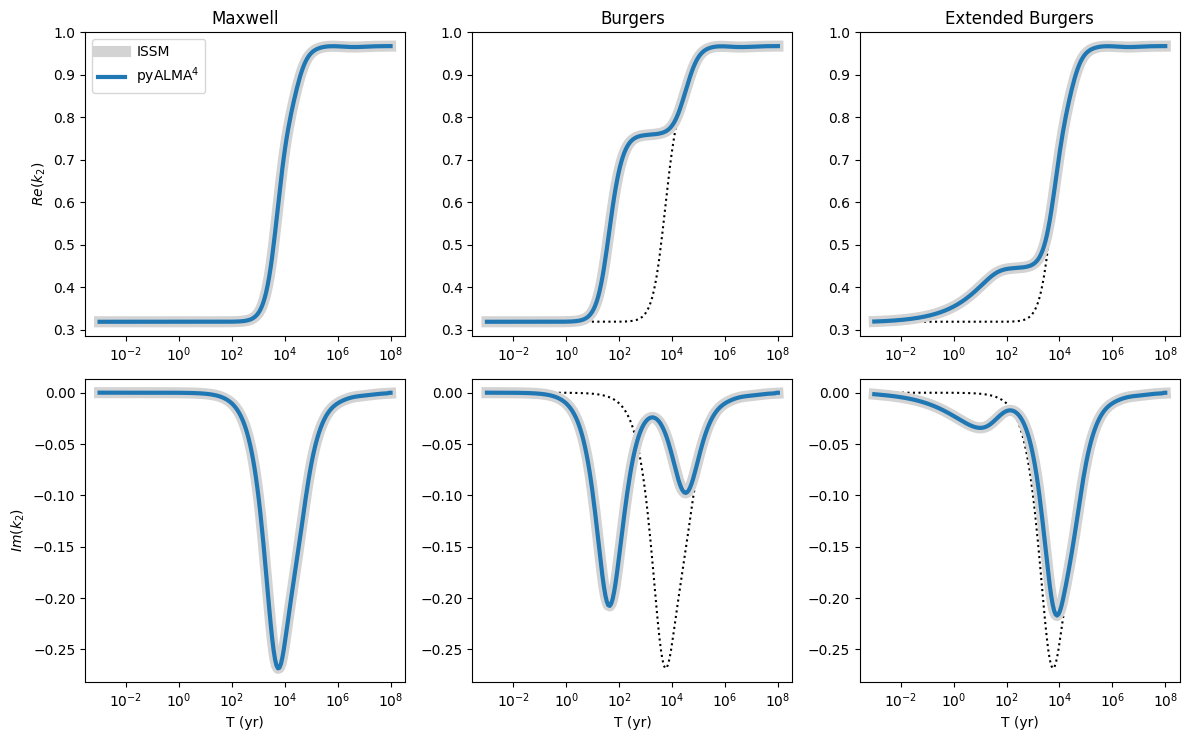

In [61]:
# Compare *compressible* LNs fromm pyALMA and ISSM

lw1, lw2 = 8, 3

fig, ax = plt.subplots( 2,3, figsize=(12,7.5) )

k=0

for i in range(2):
    for j in range(3):
        if j==0:
            k_alma, k_issm = kc_tide_mx, kc_tide_mx_issm
        elif j==1:
            k_alma, k_issm = kc_tide_bg, kc_tide_bg_issm
        elif j==2:
            k_alma, k_issm = kc_tide_eb, kc_tide_eb_issm
        if i==0:
            y_alma = np.real(k_alma)
            y_issm = np.real(k_issm)
        elif i==1:
            y_alma = np.imag(k_alma)
            y_issm = np.imag(k_issm)
            
        y_alma = np.squeeze(y_alma)

        if j==0:
            y_alma_mx = np.copy(y_alma)

        if j!=0:
            ax[i,j].semilogx( Tyr, y_alma_mx, 'k:' )    
        
        ax[i,j].semilogx( Tyr_issm, y_issm, linewidth=lw1, color='lightgray', label='ISSM' )
        ax[i,j].semilogx( Tyr,      y_alma, linewidth=lw2, label='pyALMA${}^4$' )
    

for i in range(3):
    ax[1,i].set_xlabel('T (yr)')

ax[0,0].set_ylabel('$Re(k_2)$')
ax[1,0].set_ylabel('$Im(k_2)$')

ax[0,0].legend()

ax[0,0].set_title('Maxwell')
ax[0,1].set_title('Burgers')
ax[0,2].set_title('Extended Burgers')


plt.tight_layout()

